# 6. Model Değerlendirme
Bu notebook, eğitilen 5 farklı modelin (Logistic Regression, SVM, LSTM, BiLSTM, CNN+LSTM) performanslarını kapsamlı grafikler (Confusion Matrix, ROC, PR Curves, Radar Chart vb.) ile karşılaştırır.

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow.keras.models import load_model
import plotly.express as px
import plotly.graph_objects as go
import scipy.sparse

os.makedirs('results', exist_ok=True)

print("Modeller yükleniyor...")
best_lr = joblib.load('models/lr_model.pkl')
calibrated_svm = joblib.load('models/svm_model.pkl')
model_lstm = load_model('models/lstm_model.h5')
model_bilstm = load_model('models/bilstm_model.h5')
model_cnn_lstm = load_model('models/cnn_lstm_model.h5')

print("Test verileri yükleniyor...")
df = pd.read_csv('data/reviews_preprocessed.csv')
df = df.dropna(subset=['cleaned_text'])

tfidf_vectorizer = joblib.load('models/tfidf_vectorizer.pkl')
scaler = joblib.load('models/scaler.pkl')

idx_test = np.load('features/test_idx.npy')
y = np.load('features/labels.npy')
y_test = y[idx_test]

# Klasik modeller için TF-IDF test setini hazırlama
numeric_features = ['review_length', 'word_count', 'exclamation_count', 'question_count',
                    'avg_word_length', 'uppercase_ratio', 'sentiment_polarity', 'sentiment_subjectivity']
X_tfidf = tfidf_vectorizer.transform(df['cleaned_text'])
X_numeric = scaler.transform(df[numeric_features])
X_combined = scipy.sparse.hstack([X_tfidf, X_numeric]).tocsr()
X_test_tfidf = X_combined[idx_test]

# Derin öğrenme için Sequence test setini hazırlama
X_seq = np.load('features/sequences.npy')
X_test_seq = X_seq[idx_test]

# Test metinlerini hata analizi için sakla
texts_test = df['text'].iloc[idx_test].values

print("Tahminler yapılıyor (Olasılıklar hesaplanıyor)...")
y_probs_lr = best_lr.predict_proba(X_test_tfidf)
y_probs_svm = calibrated_svm.predict_proba(X_test_tfidf)
y_probs_lstm = model_lstm.predict(X_test_seq)
y_probs_bilstm = model_bilstm.predict(X_test_seq)
y_probs_cnn_lstm = model_cnn_lstm.predict(X_test_seq)

model_probs = {
    'Logistic Regression': y_probs_lr,
    'SVM': y_probs_svm,
    'LSTM': y_probs_lstm,
    'BiLSTM': y_probs_bilstm,
    'CNN+LSTM': y_probs_cnn_lstm
}

model_preds = {name: np.argmax(probs, axis=1) for name, probs in model_probs.items()}
class_names = ["Kötü", "Orta", "İyi"]
print("Tüm test verileri ve tahminleri hazır!")


c:\Users\TAHA\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Modeller yükleniyor...


Test verileri yükleniyor...
Tahminler yapılıyor (Olasılıklar hesaplanıyor)...
7637/7637 ━━━━━━━━━━━━━━━━━━━━ 244s 32ms/step
7637/7637 ━━━━━━━━━━━━━━━━━━━━ 760s 99ms/step
7637/7637 ━━━━━━━━━━━━━━━━━━━━ 181s 24ms/step
Tüm test verileri ve tahminleri hazır!








## 6.1 Confusion Matrix
Tüm modellerin karmaşıklık matrislerini hem sayısal hem de normalize (yüzdelik) değerlerle yan yana inceleyelim.

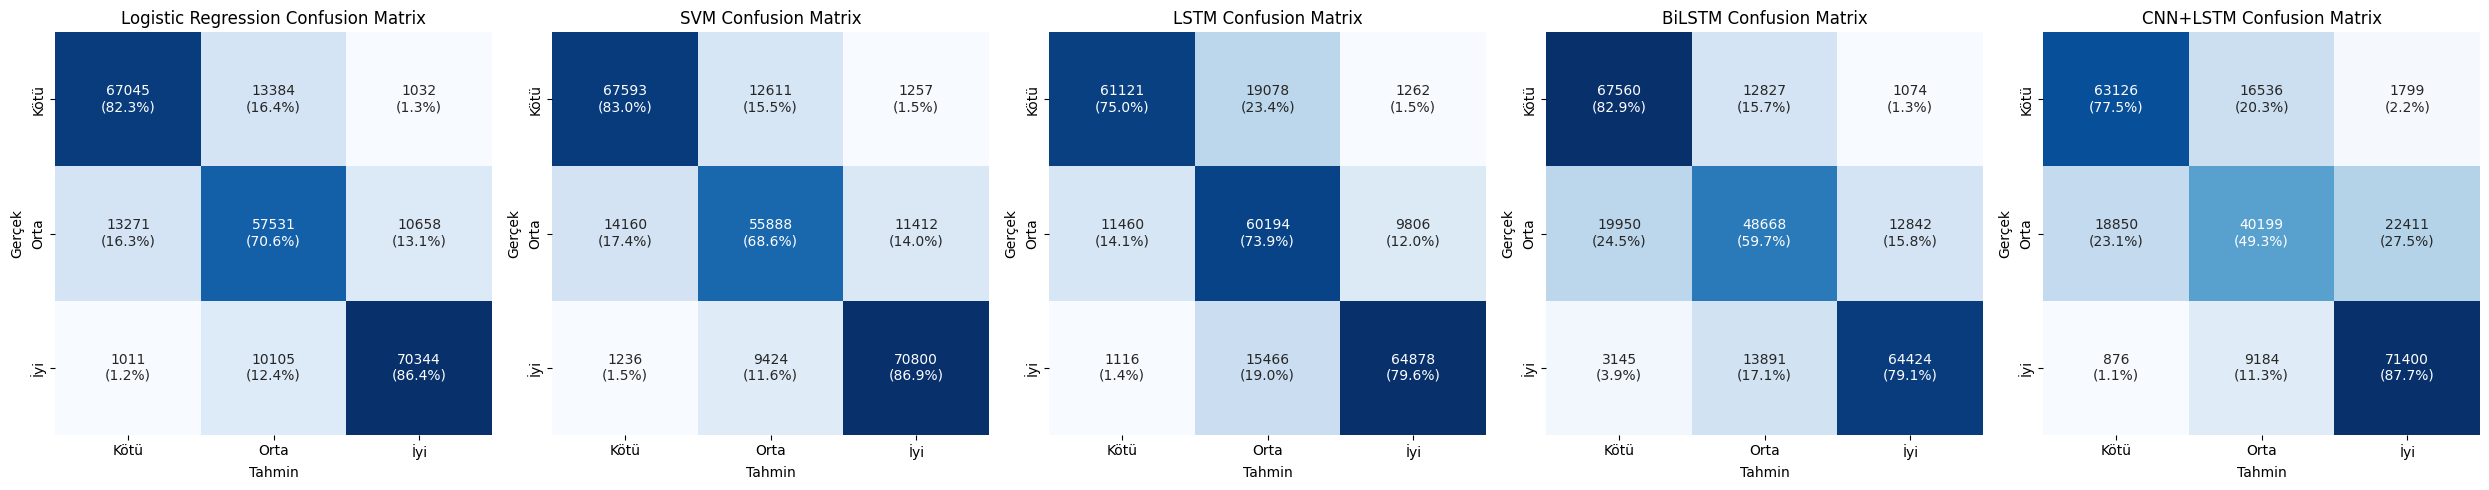

In [2]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, (name, y_pred) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
    
    annot_labels = np.empty_like(cm, dtype=object)
    for i in range(3):
        for j in range(3):
            annot_labels[i, j] = f"{cm[i,j]}\n({cm_norm[i,j]:.1%})"
            
    sns.heatmap(cm_norm, annot=annot_labels, fmt='', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Tahmin')
    ax.set_ylabel('Gerçek')
    
    fig_single = plt.figure(figsize=(6, 5))
    sns.heatmap(cm_norm, annot=annot_labels, fmt='', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Tahmin')
    plt.ylabel('Gerçek')
    plt.savefig(f'results/confusion_matrix_{name.replace(" ", "_").replace("+", "_")}.png', bbox_inches='tight')
    plt.close(fig_single)

plt.tight_layout()
plt.savefig('results/confusion_matrices_all.png', bbox_inches='tight')
plt.show()


## 6.2 ROC Curve
Receiver Operating Characteristic (ROC) eğrileri. Çok sınıflı problem için One-vs-Rest (Bire Karşı Hepsi) yaklaşımı kullanılır.

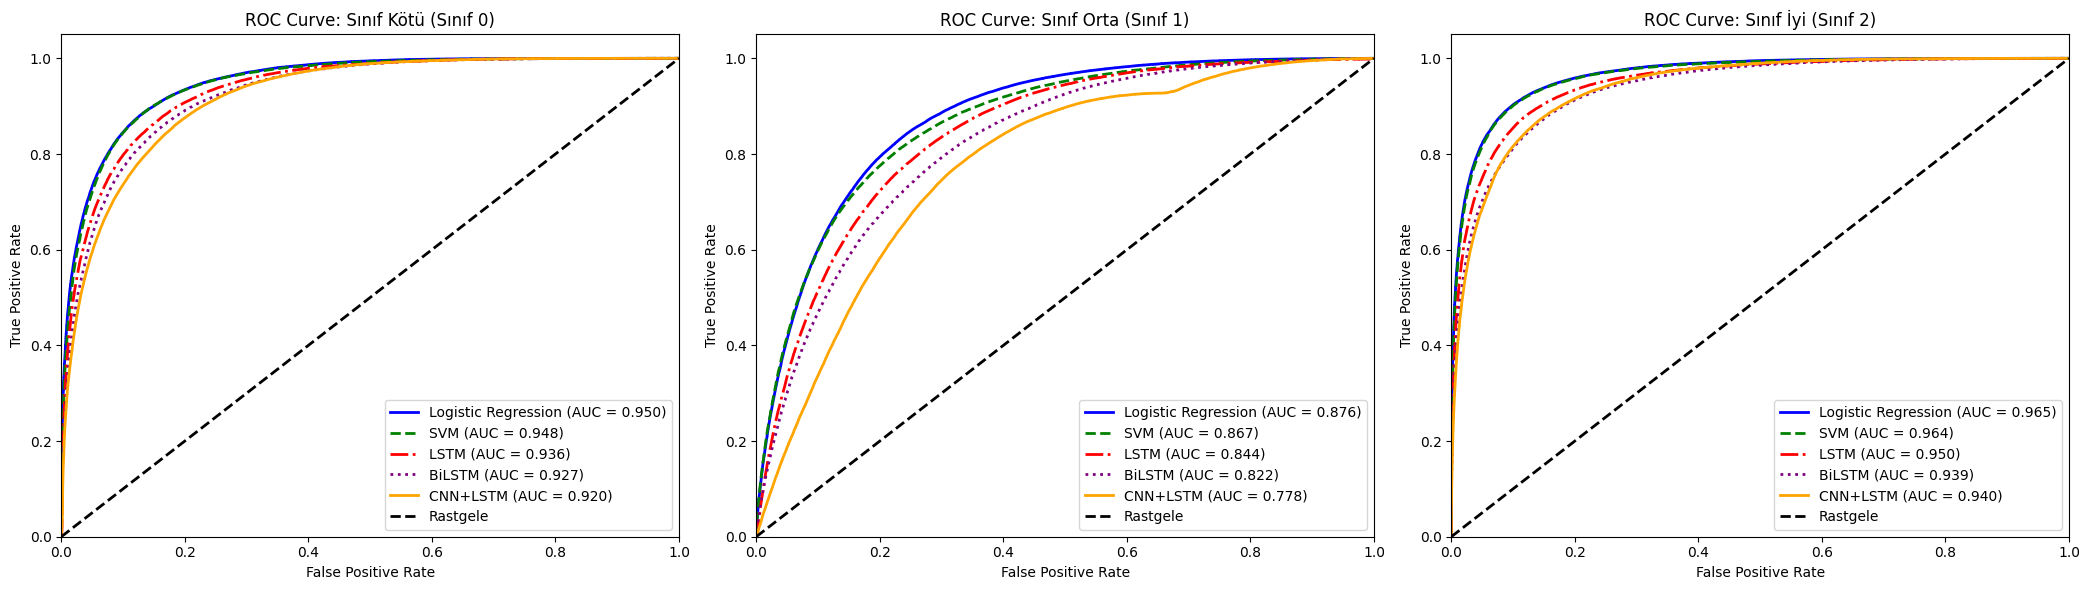

In [3]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
colors = ['blue', 'green', 'red', 'purple', 'orange']
linestyles = ['-', '--', '-.', ':', '-']

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for i, class_name in enumerate(class_names):
    ax = axes[i]
    for (name, probs), color, ls in zip(model_probs.items(), colors, linestyles):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linestyle=ls, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
        
    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Rastgele')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve: Sınıf {class_name} (Sınıf {i})')
    ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig('results/roc_curves_all.png', bbox_inches='tight')
plt.show()


## 6.3 Precision-Recall Curve
Özellikle dengesiz sınıflarda veya nadir örnekleri yakalamaya çalışırken Precision-Recall eğrileri daha bilgilendiricidir.

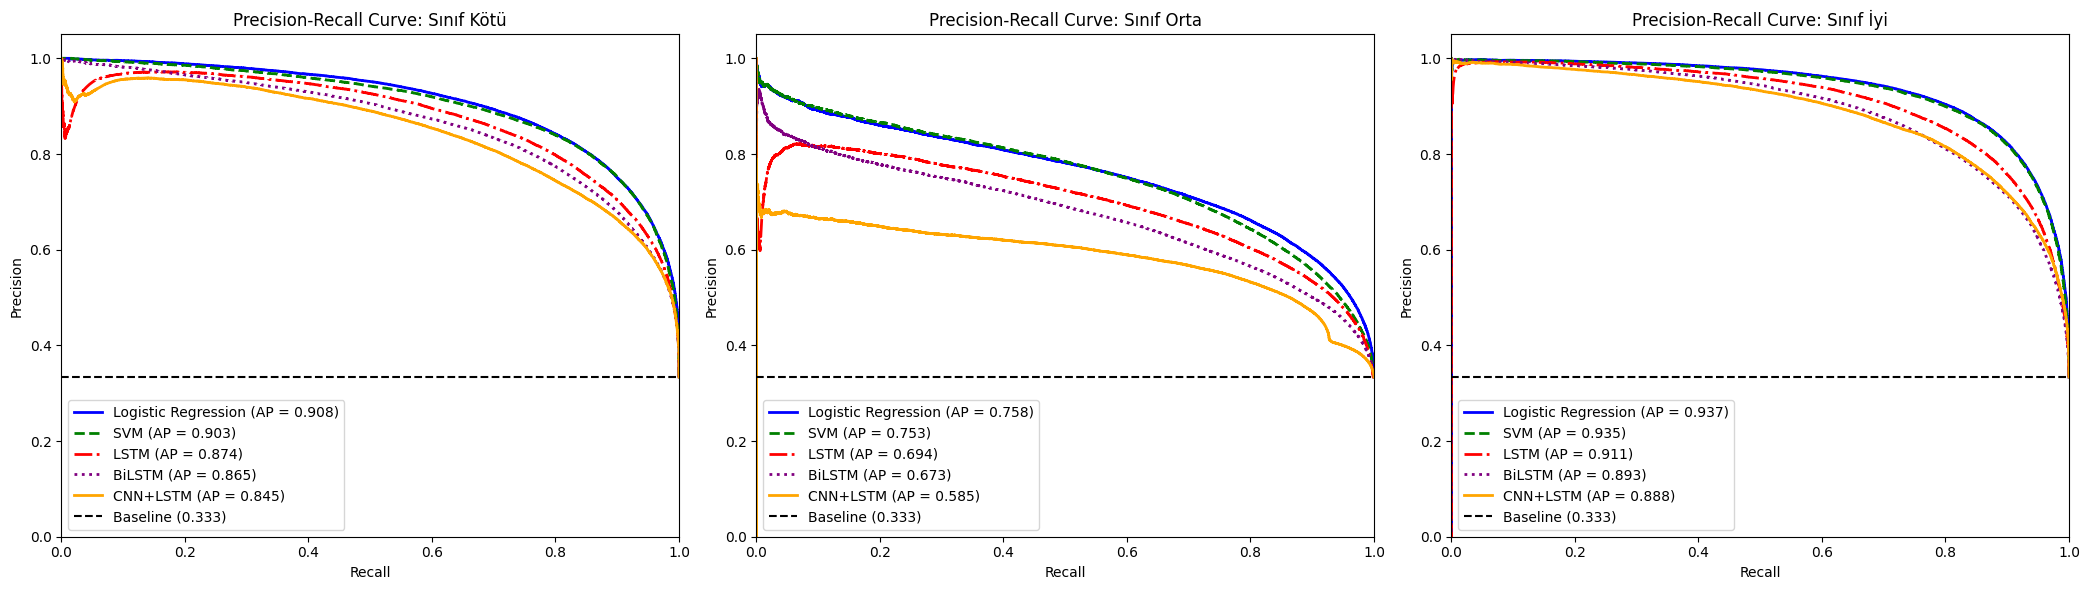

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for i, class_name in enumerate(class_names):
    ax = axes[i]
    baseline = np.sum(y_test_bin[:, i]) / len(y_test_bin[:, i])
    
    for (name, probs), color, ls in zip(model_probs.items(), colors, linestyles):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        avg_pr = average_precision_score(y_test_bin[:, i], probs[:, i])
        ax.plot(recall, precision, color=color, linestyle=ls, lw=2, label=f'{name} (AP = {avg_pr:.3f})')
        
    ax.axhline(y=baseline, color='k', linestyle='--', label=f'Baseline ({baseline:.3f})')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall Curve: Sınıf {class_name}')
    ax.legend(loc="lower left")

plt.tight_layout()
plt.savefig('results/pr_curves_all.png', bbox_inches='tight')
plt.show()


## 6.4 Model Karşılaştırma Grafikleri
Tüm metrikleri Plotly ile interaktif bar chart ve Matplotlib ile Radar Chart (Örümcek Ağı) formatında gösterir.

In [5]:
def get_metrics_dict(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro'),
        'Recall': recall_score(y_true, y_pred, average='macro'),
        'F1-Macro': f1_score(y_true, y_pred, average='macro')
    }

metrics_data = {name: get_metrics_dict(y_test, preds) for name, preds in model_preds.items()}
df_metrics = pd.DataFrame(metrics_data).T.reset_index().rename(columns={'index': 'Model'})
df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

fig = px.bar(df_melted, x='Model', y='Score', color='Metric', barmode='group',
             text='Score', title='Modellerin Genel Metrik Karşılaştırması')
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_layout(yaxis=dict(range=[0, 1]))
fig.write_image('results/model_comparison_bar.png')
fig.show()


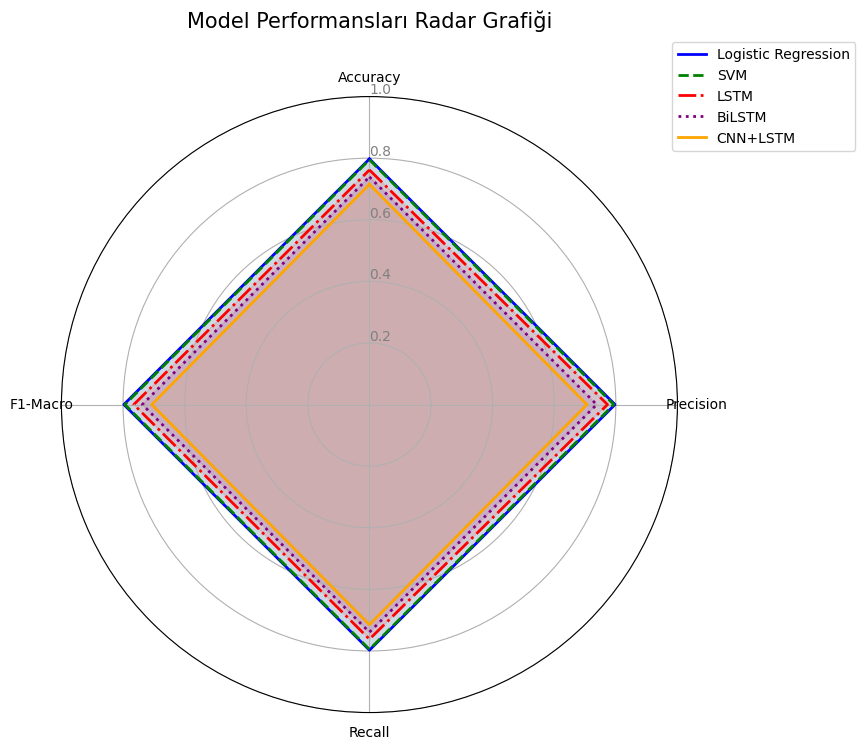

In [6]:
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Macro']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], categories)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
plt.ylim(0, 1)

for (name, metrics), color, ls in zip(metrics_data.items(), colors, linestyles):
    values = [metrics['Accuracy'], metrics['Precision'], metrics['Recall'], metrics['F1-Macro']]
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, linestyle=ls, label=name)
    ax.fill(angles, values, color=color, alpha=0.1)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title("Model Performansları Radar Grafiği", size=15, y=1.1)
plt.savefig('results/model_comparison_radar.png', bbox_inches='tight')
plt.show()


## 6.5 Training History (Derin Öğrenme)
Derin öğrenme modellerinin eğitim sırasındaki Loss ve Accuracy gelişimlerini inceleyelim (Aşırı öğrenme / Overfitting analizi).

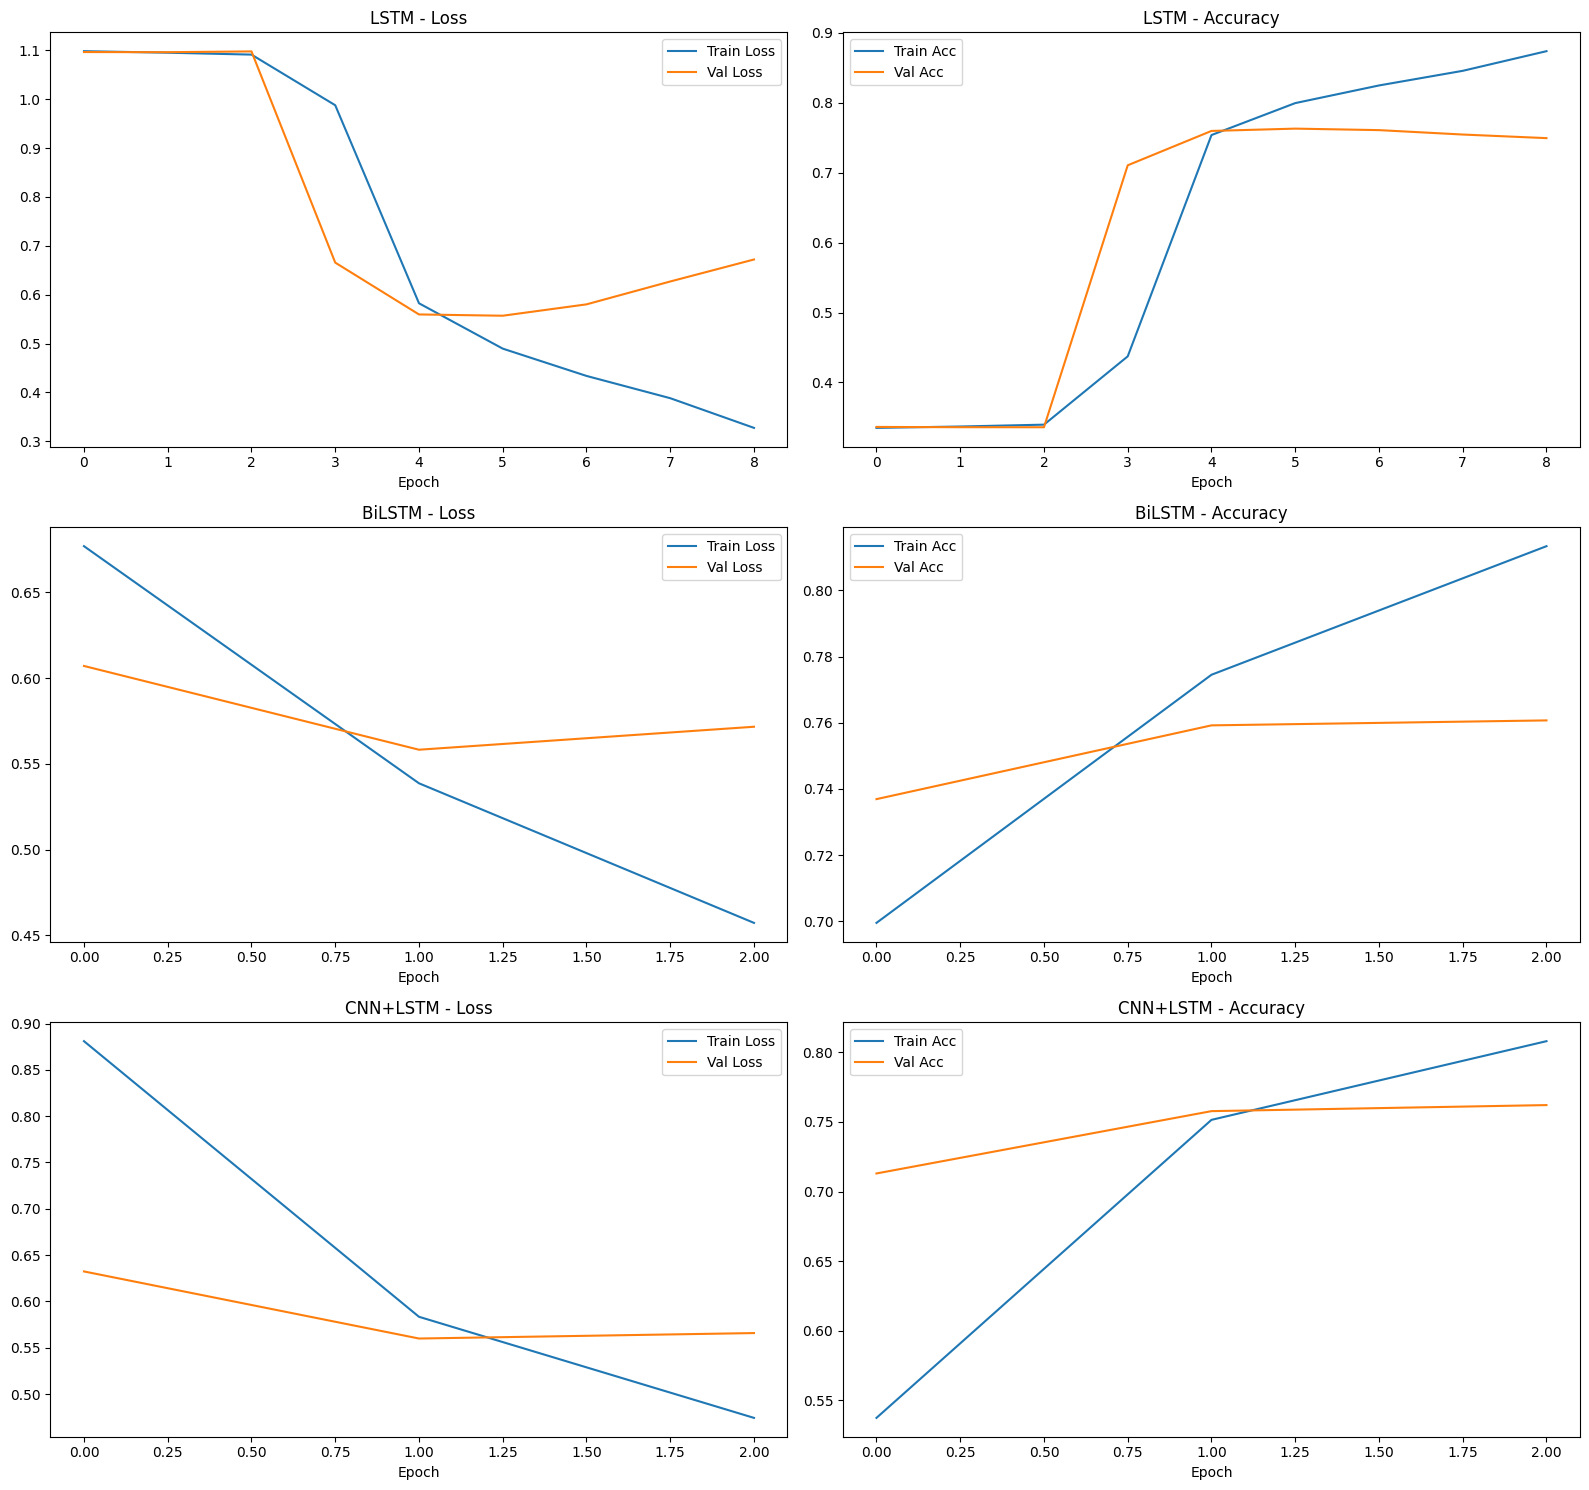

In [7]:
dl_models = ['lstm', 'bilstm', 'cnn_lstm']
titles = ['LSTM', 'BiLSTM', 'CNN+LSTM']

fig, axes = plt.subplots(3, 2, figsize=(16, 15))

for i, (model_key, title) in enumerate(zip(dl_models, titles)):
    history_file = f'results/history_{model_key}.json'
    if os.path.exists(history_file):
        with open(history_file, 'r') as f:
            history = json.load(f)
            
        axes[i, 0].plot(history['loss'], label='Train Loss')
        axes[i, 0].plot(history['val_loss'], label='Val Loss')
        axes[i, 0].set_title(f'{title} - Loss')
        axes[i, 0].set_xlabel('Epoch')
        axes[i, 0].legend()
        
        axes[i, 1].plot(history['accuracy'], label='Train Acc')
        axes[i, 1].plot(history['val_accuracy'], label='Val Acc')
        axes[i, 1].set_title(f'{title} - Accuracy')
        axes[i, 1].set_xlabel('Epoch')
        axes[i, 1].legend()

plt.tight_layout()
plt.savefig('results/training_histories.png', bbox_inches='tight')
plt.show()


## 6.6 Hata Analizi
En iyi performans gösteren modelin hangi tür yorumlarda hata yaptığını detaylı olarak inceleyelim.

Hata Analizi için En İyi Model Seçildi: Logistic Regression
Toplam Test Örneği: 244381
Hatalı Tahmin Sayısı: 49461 (Hata Oranı: %20.24)


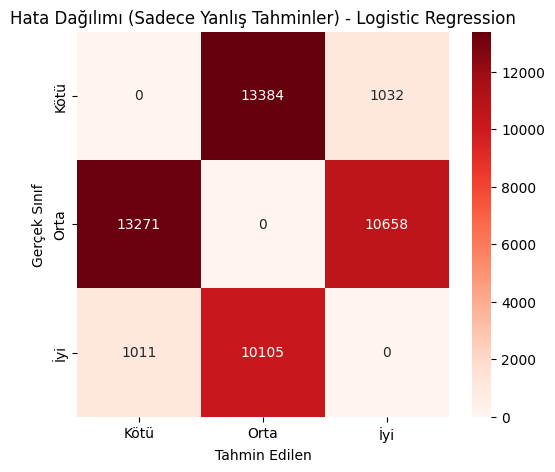

In [8]:
best_model_name = df_metrics.loc[df_metrics['F1-Macro'].idxmax(), 'Model']
print(f"Hata Analizi için En İyi Model Seçildi: {best_model_name}")

y_pred_best = model_preds[best_model_name]
y_probs_best = model_probs[best_model_name]

errors_mask = y_test != y_pred_best
print(f"Toplam Test Örneği: {len(y_test)}")
print(f"Hatalı Tahmin Sayısı: {errors_mask.sum()} (Hata Oranı: %{errors_mask.mean()*100:.2f})")

error_cm = confusion_matrix(y_test[errors_mask], y_pred_best[errors_mask])
plt.figure(figsize=(6, 5))
sns.heatmap(error_cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Hata Dağılımı (Sadece Yanlış Tahminler) - {best_model_name}')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Sınıf')
plt.savefig('results/error_analysis.png', bbox_inches='tight')
plt.show()


In [9]:
predicted_probs = np.max(y_probs_best[errors_mask], axis=1)
error_indices = np.where(errors_mask)[0]

sorted_error_idxs = error_indices[np.argsort(predicted_probs)[::-1]]

print("\n--- En Yüksek Güvenle YANLIŞ Tahmin Edilen 10 Örnek ---")
error_records = []
for idx in sorted_error_idxs[:10]:
    true_class = class_names[y_test[idx]]
    pred_class = class_names[y_pred_best[idx]]
    confidence = np.max(y_probs_best[idx])
    text_snippet = str(texts_test[idx])[:100].replace('\n', ' ') + "..."
    error_records.append([text_snippet, true_class, pred_class, f"%{confidence*100:.1f}"])

error_df = pd.DataFrame(error_records, columns=['Yorum (İlk 100 Karakter)', 'Gerçek', 'Tahmin', 'Güven'])
display(error_df)



--- En Yüksek Güvenle YANLIŞ Tahmin Edilen 10 Örnek ---


,Yorum (İlk 100 Karakter),Gerçek,Tahmin,Güven
0,LMAO So here's how joey's works - 1) wait 6 ...,Kötü,İyi,%100.0
1,My friends and I stumbled upon this gem of a J...,Orta,İyi,%100.0
2,"Loved the fried avocado! Wow, amazing! Tacos w...",Orta,İyi,%100.0
3,Very good for takeout!! They give u everything...,Orta,İyi,%99.9
4,I visited NOLA on a Saturday night in March. W...,Orta,İyi,%99.9
5,"I love this place, never disappoints ! Great f...",Orta,İyi,%99.9
6,Many dishes at this brunch were good and some ...,Orta,Kötü,%99.9
7,I pass this place all the time and I decided t...,Orta,Kötü,%99.9
8,If you are ever in doubt ask for Zach. He has ...,Orta,İyi,%99.8
9,Took my family to Zorba's to celebrate my son'...,Orta,Kötü,%99.8


## 6.7 Final Özet
Değerlendirme metriklerinin tamamını tek bir tablo olarak kaydet.

In [10]:
df_metrics.set_index('Model', inplace=True)

styled_df = df_metrics.style.highlight_max(axis=0, color='lightgreen')\
                            .format("{:.4f}")

display(styled_df)

df_metrics.to_csv('results/final_evaluation.csv')
print("\n✅ Değerlendirme tamamlandı! Tüm metrikler results/final_evaluation.csv olarak kaydedildi.")


,Accuracy,Precision,Recall,F1-Macro
Model,,,,
Logistic Regression,0.7976,0.7973,0.7976,0.7975
SVM,0.7950,0.7933,0.7950,0.7940
LSTM,0.7619,0.7730,0.7619,0.7651
BiLSTM,0.7392,0.7377,0.7392,0.7373
CNN+LSTM,0.7150,0.7062,0.7150,0.7068



✅ Değerlendirme tamamlandı! Tüm metrikler results/final_evaluation.csv olarak kaydedildi.


## 6.5 Örnek Yorumlar Üzerinde Tahmin Karşılaştırması
Test veri setinden rastgele 10 yorum seçip, 5 farklı modelimizin bu yorumlar için hangi tahminleri ürettiğini yan yana görelim.

In [11]:
import numpy as np
import pandas as pd
from IPython.display import display, HTML

np.random.seed(42)
sample_indices = np.random.choice(len(texts_test), 10, replace=False)

results_list = []
for idx in sample_indices:
    results_list.append({
        'Yorum (İlk 150 Karakter)': str(texts_test[idx])[:150] + ('...' if len(str(texts_test[idx])) > 150 else ''),
        'Gerçek': class_names[y_test[idx]],
        'LogReg': class_names[model_preds['Logistic Regression'][idx]],
        'SVM': class_names[model_preds['SVM'][idx]],
        'LSTM': class_names[model_preds['LSTM'][idx]],
        'BiLSTM': class_names[model_preds['BiLSTM'][idx]],
        'CNN+LSTM': class_names[model_preds['CNN+LSTM'][idx]]
    })

df_samples = pd.DataFrame(results_list)

def highlight_correct(val, true_val):
    if val == true_val:
        return 'background-color: lightgreen'
    elif val in class_names:
        return 'background-color: lightcoral'
    return ''

styled_df = df_samples.style.apply(lambda x: [highlight_correct(v, x['Gerçek']) for v in x], axis=1)\
                            .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
display(styled_df)


,Yorum (İlk 150 Karakter),Gerçek,LogReg,SVM,LSTM,BiLSTM,CNN+LSTM
0,I purchased a cheese burger went home took a couple bites & realized it wasn't cooked all the way. So I threw it away. I was very disappointed & they ...,Kötü,Kötü,Kötü,Kötü,Kötü,Kötü
1,I find it a little shocking that this was rated as the best Chinese restaurant in the US. The food is mediocre and overpriced. If you want overprice...,Orta,Orta,Orta,Orta,Orta,Kötü
2,"We stopped in for lunch, and 3 of us shared the vegetarian platter with hummus, baba ganoush, pita bread, stuffed grape leaves, and falafel. It was a...",İyi,İyi,İyi,İyi,İyi,İyi
3,Went here today at Swan Brewing in Lakeland. I always try and support local food trucks. Worst experience ever .For $12 their lobster roll sandwich is...,Kötü,Kötü,Kötü,Kötü,Kötü,Kötü
4,Not sure how you screw up a margherita pizza but Goodfellas figured it out. All our pizzas were soggy and lacked flavor.,Kötü,Kötü,Kötü,Kötü,Kötü,Kötü
5,"An exceptional dinning experience from start to finish. Be it the food or the service, JG SkyHigh / The Four Seasons delivers. I recently visited for ...",İyi,İyi,İyi,İyi,İyi,İyi
6,"This is a very swanky bar with a fantastic view of the city- arch, into the stadium, all from one roof. The decor is modern but not offputting. This i...",Orta,Orta,Orta,Orta,Orta,Orta
7,Worst I've tried. Let's start with the two girls that were working today. The one with bright blue hair was smart but needed to tie her hair back so...,Kötü,Kötü,Kötü,Kötü,Kötü,Kötü
8,"We landed at PHL for a long weekend in hometown Philly. For cost reasons, we were staying at a hotel in southern burb area and the hotel's only recomm...",İyi,İyi,İyi,İyi,Orta,İyi
9,"I like Mumbai Bistro because it's a place you can go to when you get a craving for Indian food on the cheap ($4.95/lb bar, $1 samosas) or even somethi...",İyi,Orta,Orta,Orta,Orta,Orta


## 6.6 Açıklanabilir Yapay Zeka (XAI) - LIME
Modellerimizin karar verirken bir nevi "kara kutu (black box)" gibi davranmasını istemiyoruz. **LIME (Local Interpretable Model-agnostic Explanations)** kullanarak, modelin bir yorumu "İyi" veya "Kötü" olarak sınıflandırmasına neden olan spesifik kelimeleri analiz ediyoruz.

In [12]:
import numpy as np
from lime.lime_text import LimeTextExplainer
import scipy.sparse

# Rastgele bir test örneği seçelim
np.random.seed(42)
sample_index = np.random.choice(len(texts_test))
sample_text = str(texts_test[sample_index])
true_label = class_names[y_test[sample_index]]

# Orijinal metnin sayısal (numeric) özelliklerini Test setinin matrisinden doğrudan alalım
# X_test_tfidf sparse bir CSR matrisidir ve son 8 sütunu sayısal özelliklerdir
original_numeric = X_test_tfidf[sample_index, -len(numeric_features):].toarray()  # (1, 8)

# LIME sadece metinleri bozarak (perturbation) yeni metinler üretir.
# Modelimiz ise Metin (TF-IDF) + Sayısal veriler beklemektedir.
# Bu yüzden LIME'ın ürettiği yeni metinleri TF-IDF'e çevirip, yanlarına orijinal yorumun sayısal verilerini ekleyen özel bir fonksiyon yazıyoruz:
def custom_predict_proba(texts_list):
    tfidf_matrix = tfidf_vectorizer.transform(texts_list)
    # Aynı sayısal veriyi tüm LIME kopyaları için çoğalt
    num_matrix = np.repeat(original_numeric, len(texts_list), axis=0)
    combined_matrix = scipy.sparse.hstack([tfidf_matrix, scipy.sparse.csr_matrix(num_matrix)])
    return best_lr.predict_proba(combined_matrix)

print("LIME modeli açıklıyor, lütfen bekleyin (yaklaşık 10-15 saniye)...")
explainer = LimeTextExplainer(class_names=class_names)
exp = explainer.explain_instance(sample_text, custom_predict_proba, num_features=10, top_labels=1)

print(f"\nOrijinal Yorum: {sample_text[:200]}...")
print(f"Gerçek Sınıf: {true_label}")
print(f"Model Tahmini: {class_names[np.argmax(custom_predict_proba([sample_text])[0])]}")

# Sonucu HTML olarak kaydet ve göster
exp.save_to_file('results/lime_explanation.html')
print("\n✅ LIME açıklaması 'results/lime_explanation.html' olarak kaydedildi!")
exp.show_in_notebook(text=True)


LIME modeli açıklıyor, lütfen bekleyin (yaklaşık 10-15 saniye)...

Orijinal Yorum: Jack's is awesome. Neil rocks. Best place ever....
Gerçek Sınıf: İyi
Model Tahmini: İyi

✅ LIME açıklaması 'results/lime_explanation.html' olarak kaydedildi!
